In [ ]:
import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel, GPT2Config
#from peft import PeftModel, LoraConfig, get_peft_model
from torch.utils.data import DataLoader, Dataset
from transformers import AdamW, get_linear_schedule_with_warmup
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.corpus import stopwords

In [ ]:
file1_path = '/content/drive/MyDrive/w266finaldatasets/train.csv'
file2_path = '/content/drive/MyDrive/w266finaldatasets/eval.csv'
file3_path = '/content/drive/MyDrive/w266finaldatasets/test.csv'

In [ ]:
train_embeddings = np.load('/content/drive/MyDrive/w266finaldatasets/train_ESM2_t12_35M_embeddings.npy')
eval_embeddings = np.load('/content/drive/MyDrive/w266finaldatasets/eval_ESM2_t12_35M_embeddings.npy')
test_embeddings = np.load('/content/drive/MyDrive/w266finaldatasets/test_ESM2_t12_35M_embeddings.npy')

train_embeddings_list = [embedding.tolist() for embedding in train_embeddings]
eval_embeddings_list = [embedding.tolist() for embedding in eval_embeddings]
test_embeddings_list = [embedding.tolist() for embedding in test_embeddings]

train_df = pd.DataFrame({'ESM2_embeddings': list(train_embeddings_list)})
eval_df = pd.DataFrame({'ESM2_embeddings': list(eval_embeddings_list)})
test_df = pd.DataFrame({'ESM2_embeddings': list(test_embeddings_list)})
print(len(train_df))
print(len(eval_df))
print(len(test_df))




FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/w266finaldatasets/train_ESM2_t12_35M_embeddings.npy'

In [ ]:
df1 = pd.read_csv(file1_path)
df2 = pd.read_csv(file2_path)
df3 = pd.read_csv(file3_path)

merge_df1 = pd.concat([df1,train_df], axis=1)
merge_df2 = pd.concat([df2, eval_df], axis=1)
merge_df3 = pd.concat([df3, test_df], axis=1)

train_merge_df = merge_df1



In [ ]:
import torch.nn.functional as F
train_sample = merge_df1.sample(n=10, random_state=42)
test_sample = merge_df3.sample(n=10, random_state=42)

train_embeddings_list = train_sample['ESM2_embeddings'].apply(lambda x: torch.tensor(x) if not isinstance(x, torch.Tensor) else x)
test_embeddings_list = test_sample['ESM2_embeddings'].apply(lambda x: torch.tensor(x) if not isinstance(x, torch.Tensor) else x)

embeddings1 = torch.stack(list(train_embeddings_list))
embeddings2 = torch.stack(list(test_embeddings_list))


embeddings1 = F.normalize(embeddings1, p=2, dim=1)
embeddings2 = F.normalize(embeddings2, p=2, dim=1)

cosine_similarity_matrix = torch.mm(embeddings1, embeddings2.T).numpy()

In [ ]:
cosine_similarity_matrix_1 = torch.mm(embeddings1, embeddings1.T).numpy()

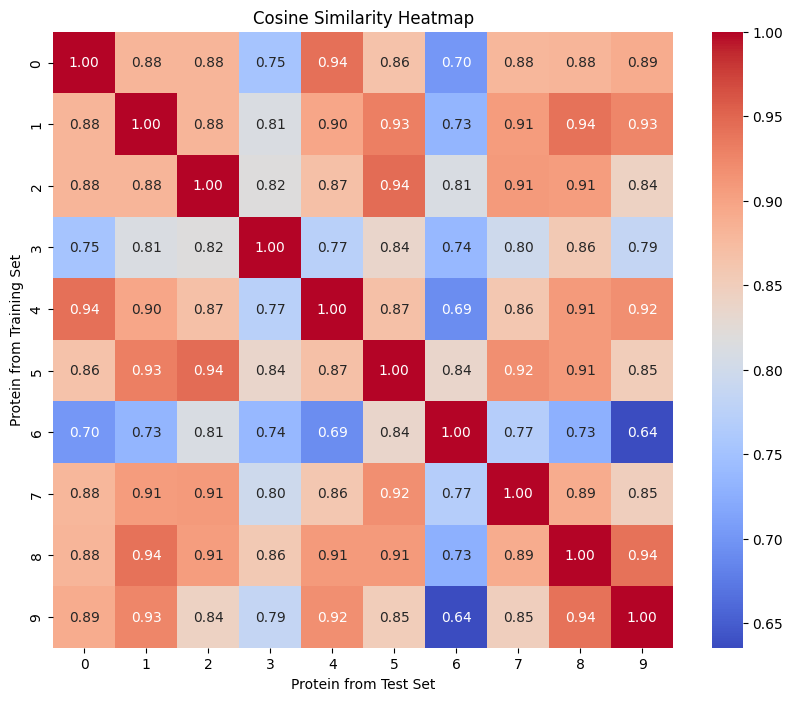

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_similarity_matrix_1, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Cosine Similarity Heatmap')
plt.xlabel('Protein from Test Set')
plt.ylabel('Protein from Test Set')
plt.show()

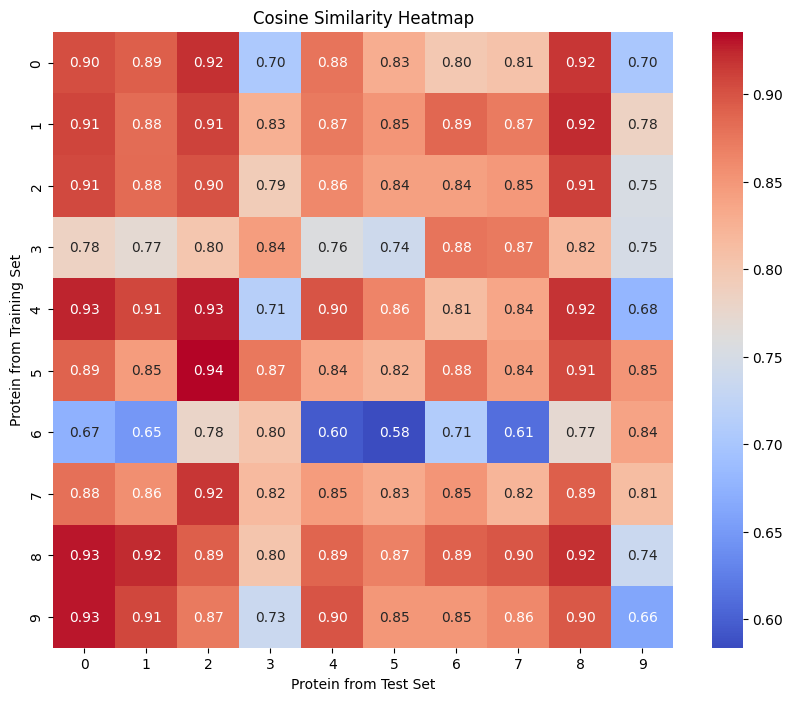

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_similarity_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Cosine Similarity Heatmap')
plt.xlabel('Protein from Test Set')
plt.ylabel('Protein from Training Set')
plt.show()


In [ ]:
len(train_merge_df)

248315

In [ ]:
num_unique_functions = train_merge_df['function'].nunique()

print(f"Number of unique functions: {num_unique_functions}")

Number of unique functions: 48251


In [ ]:
num_unique_functions = df2['function'].nunique()

print(f"Number of unique functions: {num_unique_functions}")

Number of unique functions: 3513


Deduplication to get a more diverse description as we saw that if using complete training and doing cosine similairity we do get similar protein to the effect of getting the same concatenated description.

In [ ]:
unique_entries = train_merge_df.drop_duplicates(subset='function')

In [ ]:
len(unique_entries)
unique_entries.head()

,Unnamed: 0,accession,name,Full Name,taxon,sequence,function,AlphaFoldDB,ESM2_embeddings
0,0,B7LNJ1,LPLT_ESCF3,Lysophospholipid transporter LplT,Escherichia,MSESVHTNTSLWSKGMKAVIVAQFLSAFGDNALLFATLALLKAQFY...,Catalyzes the facilitated diffusion of 2-acyl-...,B7LNJ1,"[-0.020079083740711212, -0.16466514766216278, ..."
1,1,Q6LG09,OTC_PHOPR,Ornithine carbamoyltransferase,Photobacterium,MSFNLRNRNFLKLLDFTGKEIEHLIALAQDLKHAKYAGTEQQKLKG...,Reversibly catalyzes the transfer of the carba...,Q6LG09,"[-0.18515104055404663, -0.08751194924116135, 0..."
2,2,Q01345,NHEB_ONCMY,Na(+)/H(+) antiporter,Oncorhynchus,MPAFSCAFPGCRRDLLVIVLVVFVGIGLPIEASAPAYQSHGTEGSH...,Involved in pH regulation to eliminate acids g...,Q01345,"[-0.062246594578027725, -0.05022774264216423, ..."
3,3,Q54ME1,GMSA_DICDI,Gamete and mating-type specific protein A,Dictyostelium,MKLILVLLCLISTLFVVKGGLSPTEQQIIVSYHNKWRSSPIGPTPS...,Thiol protease that seems to be involved in th...,Q54ME1,"[-0.12804189324378967, -0.0032529274467378855,..."
4,4,Q8UIE8,SYW_AGRFC,Tryptophanyl-tRNA synthetase,Agrobacterium tumefaciens complex,MNAFKPLVFSGVQPTGNLHLGNYLGAIRKFVALQEDNDCIYCVVDM...,Catalyzes the attachment of tryptophan to tRNA...,Q8UIE8,"[-0.026083778589963913, -0.043228261172771454,..."


In [ ]:
import torch.nn.functional as F

In [ ]:
import gc
def clear_gpu_memory():
    torch.cuda.empty_cache()
    gc.collect()

In [ ]:
clear_gpu_memory()

In [ ]:
batch_size = 1000

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import DataLoader, TensorDataset
import csv
from tqdm import tqdm

In [ ]:
def get_batches(df, batch_size):
    num_batches = (len(df) + batch_size - 1) // batch_size
    for i in range(num_batches):
        batch_df = df.iloc[i * batch_size:(i + 1) * batch_size]
        yield batch_df

def compute_and_write_cosine_similarity(df, batch_size, output_file,threshold=0.95):
    # Open CSV file for writing
    with open(output_file, 'w', newline='') as f:
        writer = csv.writer(f)

        # Write header row
        writer.writerow(['protein_index_i', 'protein_index_j', 'cosine_similarity'])

        # DataLoader for batch processing
        embeddings = np.stack(df['ESM2_embeddings'].values)
        embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32)
        embeddings_tensor = F.normalize(embeddings_tensor, p=2, dim=1)
        dataset = TensorDataset(embeddings_tensor)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        # Compute cosine similarity in batches and write to CSV
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = torch.nn.DataParallel(torch.nn.Identity()).to(device)

        batches_processed = 0
        with torch.no_grad(), tqdm(total=len(dataloader)) as pbar:
            for batch_i, (batch_i_tensor,) in enumerate(dataloader):
                batch_i_tensor = batch_i_tensor.to(device)
                batch_i_tensor = F.normalize(batch_i_tensor, p=2, dim=1)

                for batch_j, (batch_j_tensor,) in enumerate(dataloader):
                    batch_j_tensor = batch_j_tensor.to(device)
                    batch_j_tensor = F.normalize(batch_j_tensor, p=2, dim=1)

                    # Compute cosine similarity between batch_i and batch_j_tensor
                    start_i = batch_i * batch_size
                    start_j = batch_j * batch_size
                    end_i = min(start_i + batch_size, len(embeddings))
                    end_j = min(start_j + batch_size, len(embeddings))

                    batch_cos_sim = torch.mm(batch_i_tensor, batch_j_tensor.T)

                    batch_cos_sim_cpu = batch_cos_sim.cpu()
                    for k in range(batch_cos_sim_cpu.size(0)):
                        for l in range(batch_cos_sim_cpu.size(1)):
                            if batch_cos_sim_cpu[k, l].item() >= threshold:
                                writer.writerow([start_i + k, start_j + l, batch_cos_sim_cpu[k, l].item()])

                    '''
                    # Write batch results to CSV
                    for k in range(batch_cos_sim.size(0)):
                        for l in range(batch_cos_sim.size(1)):
                            writer.writerow([start_i + k, start_j + l, batch_cos_sim[k, l].item()])
                    '''
                batches_processed += 1
                pbar.update(1)
                pbar.set_description(f"Processed batches: {batches_processed}")

In [ ]:
output_file = 'train_cosine_similarity_results.csv'
compute_and_write_cosine_similarity(test_unique_entries, batch_size, output_file)

In [ ]:
def get_top_three_similar_proteins(csv_file):
    # Read CSV file into a DataFrame
    df = pd.read_csv(csv_file)

    # Group by protein_index_i and find top 3 similar proteins
    top_three_similar = {}
    for protein_index, group in df.groupby('protein_index_i'):
        top_three = group.nlargest(3, 'cosine_similarity')[['protein_index_j', 'cosine_similarity']].values.tolist()
        top_three_similar[protein_index] = top_three

    return top_three_similar

In [ ]:
csv_file = '/content/test_cosine_similarity_results.csv'
top_three_similar = get_top_three_similar_proteins(csv_file)

In [ ]:
len(top_three_similar)

3594

In [ ]:
def extract_top_indices(top_similar_dict):
    # Dictionary to store extracted indices
    extracted_indices = {}

    for protein_index, top_similars in top_similar_dict.items():
        # Extract indices from top_similars
        top_indices = [int(similar[0]) for similar in top_similars]
        extracted_indices[protein_index] = top_indices

    return extracted_indices

# Example dictionary

# Extract indices
extracted_indices = extract_top_indices(top_three_similar)



In [ ]:
with open('/content/drive/MyDrive/w266-Project/test_topthreesimilar.pkl', 'wb') as f:
    pickle.dump(extracted_indices, f)

In [ ]:
index_to_check = 7273
description = train_merge_df.loc[index_to_check, 'function']
sequence = train_merge_df.loc[index_to_check, 'sequence']
print(f"Description for index {index_to_check}: {description}")
print(f"Description for index {index_to_check}: {sequence}")
print(len(description))

Description for index 7273: Participates actively in the response to hyperosmotic and heat shock by preventing the aggregation of stress-denatured proteins, in association with DnaK and GrpE. It is the nucleotide exchange factor for DnaK and may function as a thermosensor. Unfolded proteins bind initially to DnaJ; upon interaction with the DnaJ-bound protein, DnaK hydrolyzes its bound ATP, resulting in the formation of a stable complex. GrpE releases ADP from DnaK; ATP binding to DnaK triggers the release of the substrate protein, thus completing the reaction cycle. Several rounds of ATP-dependent interactions between DnaJ, DnaK and GrpE are required for fully efficient folding.
Description for index 7273: MSNESTNPQQEPLEQVQDTEVVTDEAALVDELTQANFRIEELEQALAAAEAKVEEQKDSVVRAAAEVDNIRRRAAMDVEKANKFALEKFANELLPVLDNMERALAGTNAEDEATKAMYEGVSLTMKTLVNAVEKFGVKVVDPMGQPFNPEQHQAIGMQPNPEVPANHVMVVLQKGYELNGRLLRPAMVMVSQGGGVDTQA
659


In [ ]:
def concatenate_descriptions(key, similar_indices, descriptions_df):
    # Retrieve the main description using the key as the index
    if key not in descriptions_df.index:
        return None  # Handle the case where the main description is not found

    main_description = descriptions_df.loc[key, 'function']

    # Initialize the list with the main description
    concatenated_descriptions = [main_description]

    # Retrieve and concatenate descriptions of the similar proteins
    for similar_index in similar_indices[-2:]:
        if similar_index in descriptions_df.index:
            similar_description = descriptions_df.loc[similar_index, 'function']
            concatenated_descriptions.append(similar_description)

    # Join descriptions into a single string
    concatenated_description = ' '.join(concatenated_descriptions)

    return concatenated_description

def process_and_concatenate(extracted_indices, descriptions_df):
    results = []

    for key, similar_indices in extracted_indices.items():
        # For each key, fetch descriptions based on the similar indices
        concatenated_description = concatenate_descriptions(key, similar_indices, descriptions_df)
        results.append({
            'key': key,
            'concatenated_description': concatenated_description
        })

    return pd.DataFrame(results)


# Process the extracted indices and get concatenated descriptions DataFrame
concatenated_df = process_and_concatenate(extracted_indices, merge_df3)






In [ ]:
print(concatenated_df)

       key                           concatenated_description
0        0  Catalyzes the ATP-dependent ligation of L-glut...
1        1  Binds to target gene promoters, including NKX2...
2        2  Functions as a motor for intraflagellar retrog...
3        3  Catalyzes the intramolecular carbocycle format...
4        4  Cytochrome c oxidase subunit which plays a rol...
...    ...                                                ...
3589  3589  Involved in the uptake of p-toluenesulphonate ...
3590  3590  Cell division protein that is involved in the ...
3591  3591  Required for CNS development: midline glial ce...
3592  3592  Plays an essential role in the repair of DNA d...
3593  3593  Probable serine/threonine protein kinase which...

[3594 rows x 2 columns]


In [ ]:
print(concatenated_df.iloc[0]['concatenated_description'])

Catalyzes the ATP-dependent ligation of L-glutamate and L-cysteine and participates in the first and rate-limiting step in glutathione biosynthesis. An essential GTPase that binds both GDP and GTP, with rapid nucleotide exchange. Plays a role in 16S rRNA processing and 30S ribosomal subunit biogenesis and possibly also in cell cycle regulation and energy metabolism. Part of the yehABCD fimbrial operon. Could contribute to adhesion to various surfaces in specific environmental niches.


In [ ]:
len(concatenated_df)

3594

In [ ]:
with open('/content/drive/MyDrive/w266-Project/test_concatDescription.pkl', 'wb') as f:
    pickle.dump(extracted_indices, f)

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')
# Load NLTK's list of English stop words
stop_words = set(stopwords.words('english'))

def remove_stop_words(text):
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(text.lower())  # Tokenize and convert to lower case
    filtered_words = [word for word in word_tokens if word not in stop_words and word.isalnum()]
    return ' '.join(filtered_words)



# Create a new dictionary to store the filtered descriptions

concatenated_df['filtered_description'] = concatenated_df['concatenated_description'].apply(remove_stop_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
print(concatenated_df)

         key                           concatenated_description  \
0          0  Catalyzes the facilitated diffusion of 2-acyl-...   
1          1  Reversibly catalyzes the transfer of the carba...   
2          2  Involved in pH regulation to eliminate acids g...   
3          3  Thiol protease that seems to be involved in th...   
4          4  Catalyzes the attachment of tryptophan to tRNA...   
...      ...                                                ...   
48246  48246  Digests double-stranded RNA. Involved in the p...   
48247  48247  One of several proteins that assist in the lat...   
48248  48248  Releases the supercoiling and torsional tensio...   
48249  48249  Probable neurotoxin. Exhibits stronger antimic...   
48250  48250  Transfers mannosyl residues to the hydroxyl gr...   

                                    filtered_description  
0      catalyzes facilitated diffusion cell participa...  
1      reversibly catalyzes transfer carbamoyl group ...  
2      involved ph

In [ ]:
file_path = '/content/drive/MyDrive/w266-Project/ESM_test_filteredDescription.csv'

# Save DataFrame to CSV
concatenated_df.to_csv(file_path, index=False, header=True)

In [ ]:
'''
split1 = final_merged_df.iloc[:len(df1)]
split2 = final_merged_df.iloc[len(df1):len(df1)+len(df2)]
split3 = final_merged_df.iloc[len(df1)+len(df2):]


split1_file = 'Train_ESM.csv'
split2_file = 'Eval_ESM.csv'
split3_file = 'Test_ESM.csv'

'''